In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')

# Check if GPU available (will use CPU on Mac, that's fine)
device = 0 if torch.cuda.is_available() else -1
print(f"Using: {'GPU' if device == 0 else 'CPU'}")
print("All imports OK")

Using: CPU
All imports OK


In [2]:
print("Loading FinBERT... (first time downloads ~500MB, be patient)")

tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
model_bert = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')

sentiment_pipeline = pipeline(
    "text-classification",
    model=model_bert,
    tokenizer=tokenizer,
    device=device,
    top_k=None  # return all 3 scores
)

print("✅ FinBERT loaded!")

Loading FinBERT... (first time downloads ~500MB, be patient)


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ FinBERT loaded!


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [3]:
def get_finbert_sentiment(text, max_chunks=5):
    """
    FinBERT max input is 512 tokens.
    We split long transcripts into chunks and average the scores.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {'positive': 0.33, 'negative': 0.33, 'neutral': 0.33}
    
    # Split into ~400 word chunks to stay under 512 token limit
    words  = text.split()
    chunks = [' '.join(words[i:i+400]) 
              for i in range(0, min(len(words), 400*max_chunks), 400)]
    
    all_scores = {'positive': [], 'negative': [], 'neutral': []}
    
    for chunk in chunks:
        if len(chunk.strip()) < 50:
            continue
        try:
            results = sentiment_pipeline(chunk[:1500])[0]
            for item in results:
                label = item['label'].lower()
                if label in all_scores:
                    all_scores[label].append(item['score'])
        except:
            continue
    
    # Average across chunks
    return {
        'positive': np.mean(all_scores['positive']) if all_scores['positive'] else 0.33,
        'negative': np.mean(all_scores['negative']) if all_scores['negative'] else 0.33,
        'neutral':  np.mean(all_scores['neutral'])  if all_scores['neutral']  else 0.33
    }

# Quick test
test = "Revenue exceeded expectations with record growth this quarter."
print(get_finbert_sentiment(test))

{'positive': np.float64(0.9535349011421204), 'negative': np.float64(0.020524704828858376), 'neutral': np.float64(0.025940313935279846)}


In [4]:
import time

df = pd.read_pickle('../data/processed/full_dataset.pkl')

# Start with 50 to test speed
sample = df.sample(50, random_state=42).copy()

sentiments = []
for i, (idx, row) in enumerate(sample.iterrows()):
    scores = get_finbert_sentiment(row['transcript'])
    scores['ticker']    = row['ticker']
    scores['date']      = row['date']
    scores['direction'] = row['direction']
    scores['pct_change']= row['pct_change']
    sentiments.append(scores)
    
    if (i+1) % 10 == 0:
        print(f"✓ {i+1}/50 done")

sent_df = pd.DataFrame(sentiments)
print(f"\nSample done!")
print(sent_df[['positive','negative','neutral','direction']].head(10))

✓ 10/50 done
✓ 20/50 done
✓ 30/50 done
✓ 40/50 done
✓ 50/50 done

Sample done!
   positive  negative   neutral  direction
0  0.272261  0.361566  0.366173          0
1  0.475657  0.061350  0.462993          1
2  0.208691  0.347745  0.443564          0
3  0.412982  0.359159  0.227858          0
4  0.542660  0.156649  0.300691          1
5  0.750358  0.021187  0.228455          1
6  0.365446  0.363982  0.270573          0
7  0.592009  0.180630  0.227361          0
8  0.732039  0.013754  0.254208          1
9  0.489960  0.018299  0.491741          0


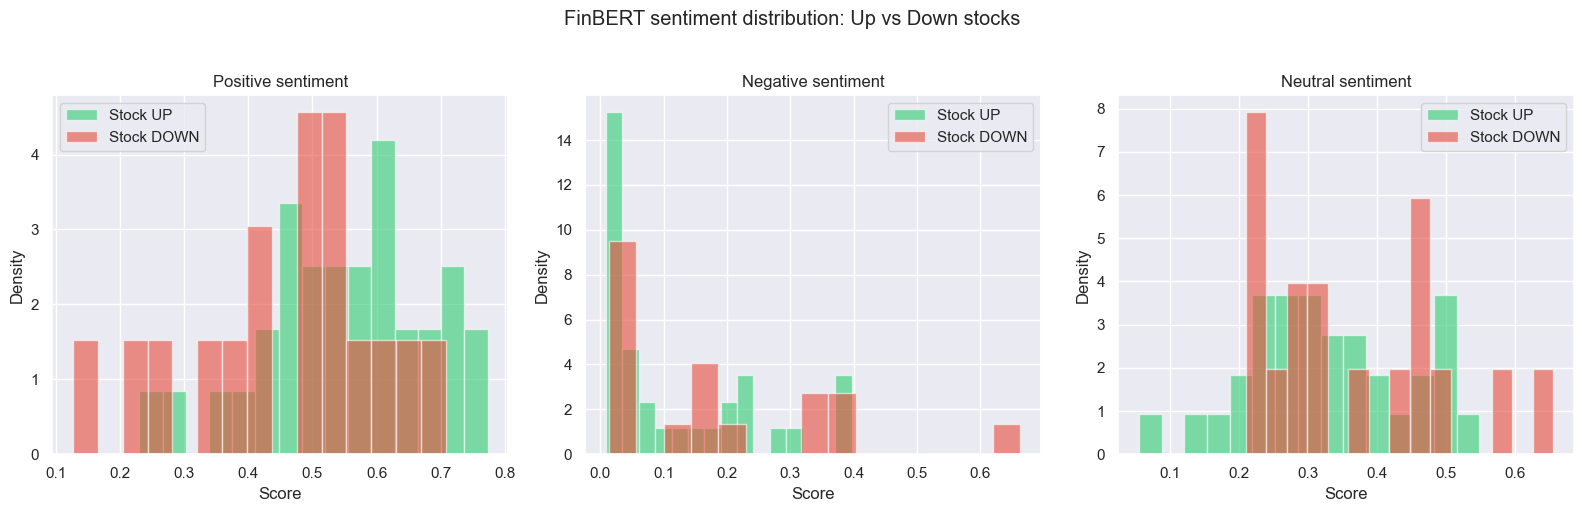


Correlation with price change:
positive      0.216799
negative     -0.120093
neutral      -0.111176
pct_change    1.000000
Name: pct_change, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    up   = sent_df[sent_df['direction']==1][sentiment]
    down = sent_df[sent_df['direction']==0][sentiment]
    
    ax.hist(up,   bins=15, alpha=0.6, color='#2ecc71', label='Stock UP',   density=True)
    ax.hist(down, bins=15, alpha=0.6, color='#e74c3c', label='Stock DOWN', density=True)
    ax.set_title(f'{sentiment.capitalize()} sentiment')
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('FinBERT sentiment distribution: Up vs Down stocks', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/nlp_sentiment_dist.png', bbox_inches='tight')
plt.show()

# Correlation
print("\nCorrelation with price change:")
print(sent_df[['positive','negative','neutral','pct_change']].corr()['pct_change'])

In [6]:
print("Running FinBERT on full dataset (~2-3 hours on CPU)")
print("Leave this running overnight if needed")

all_sentiments = []
failed = 0

for i, (idx, row) in enumerate(df.iterrows()):
    try:
        scores = get_finbert_sentiment(row['transcript'])
        scores['ticker']     = row['ticker']
        scores['date']       = row['date']
        scores['direction']  = row['direction']
        scores['pct_change'] = row['pct_change']
        scores['q']          = row['q']
        all_sentiments.append(scores)
    except:
        failed += 1

    # Save every 500 rows
    if (i+1) % 500 == 0:
        pd.DataFrame(all_sentiments).to_pickle(
            '../data/processed/sentiment_partial.pkl')
        print(f"✓ {i+1}/{len(df)} | failed: {failed}")

# Final save
sentiment_df = pd.DataFrame(all_sentiments)
sentiment_df.to_pickle('../data/processed/sentiment_scores.pkl')
print(f"\n✅ Done! {len(sentiment_df)} rows saved")

Running FinBERT on full dataset (~2-3 hours on CPU)
Leave this running overnight if needed
✓ 500/13377 | failed: 0
✓ 1000/13377 | failed: 0
✓ 1500/13377 | failed: 0
✓ 2000/13377 | failed: 0
✓ 2500/13377 | failed: 0
✓ 3000/13377 | failed: 0


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (782 > 512). Running this sequence through the model will result in indexing errors


✓ 3500/13377 | failed: 0
✓ 4000/13377 | failed: 0
✓ 4500/13377 | failed: 0
✓ 5000/13377 | failed: 0
✓ 5500/13377 | failed: 0
✓ 6000/13377 | failed: 0
✓ 6500/13377 | failed: 0
✓ 7000/13377 | failed: 0
✓ 7500/13377 | failed: 0
✓ 8000/13377 | failed: 0
✓ 8500/13377 | failed: 0
✓ 9000/13377 | failed: 0
✓ 9500/13377 | failed: 0
✓ 10000/13377 | failed: 0
✓ 10500/13377 | failed: 0
✓ 11000/13377 | failed: 0
✓ 11500/13377 | failed: 0
✓ 12000/13377 | failed: 0
✓ 12500/13377 | failed: 0
✓ 13000/13377 | failed: 0

✅ Done! 13377 rows saved


In [7]:
# Merge sentiment scores back with ML features
sent_full = pd.read_pickle('../data/processed/sentiment_scores.pkl')
sent_full['date'] = pd.to_datetime(sent_full['date'])

# Rebuild full feature set with sentiment
df_full = pd.read_pickle('../data/processed/full_dataset.pkl')
df_full['date'] = pd.to_datetime(df_full['date'])

# Feature engineering (same as ML notebook)
df_full['transcript_length'] = df_full['transcript'].str.split().str.len()
df_full['avg_word_length']   = df_full['transcript'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if pd.notna(x) else 0)
df_full['question_count']    = df_full['transcript'].str.count(r'\?')
df_full['quarter_num']       = df_full['q'].str.extract(r'Q(\d)').astype(float)
df_full['year']              = df_full['date'].dt.year

signal_words = ['growth','revenue','guidance','margin','beat','miss',
                'raised','lowered','uncertainty','headwinds','record',
                'strong','weak','declined','exceeded','profit','loss',
                'outlook','forecast','demand']
for word in signal_words:
    df_full[f'word_{word}'] = df_full['transcript'].str.lower().str.count(word)

# Merge sentiment
df_merged = df_full.merge(
    sent_full[['ticker','date','positive','negative','neutral']],
    on=['ticker','date'], how='inner')

print(f"Merged shape: {df_merged.shape}")
print(f"Sentiment columns added: positive, negative, neutral")

Merged shape: (13379, 34)
Sentiment columns added: positive, negative, neutral


In [8]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report

feature_cols_v2 = (['transcript_length','avg_word_length',
                    'question_count','quarter_num','year',
                    'positive','negative','neutral']  # ← new!
                   + [f'word_{w}' for w in signal_words])

df_ml2 = df_merged[feature_cols_v2 + ['direction']].dropna()

X2 = df_ml2[feature_cols_v2]
y2 = df_ml2['direction']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

model_v2 = LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_v2.fit(X2_train, y2_train)

y2_pred      = model_v2.predict(X2_test)
y2_pred_prob = model_v2.predict_proba(X2_test)[:, 1]

print("=" * 50)
print("MODEL V2 — with FinBERT sentiment features")
print("=" * 50)
print(classification_report(y2_test, y2_pred,
      target_names=['Down','Up']))
print(f"ROC-AUC:  {roc_auc_score(y2_test, y2_pred_prob):.4f}")

cv2 = cross_val_score(model_v2, X2, y2, cv=5, scoring='roc_auc')
print(f"5-Fold CV AUC: {cv2.mean():.4f} ± {cv2.std():.4f}")

MODEL V2 — with FinBERT sentiment features
              precision    recall  f1-score   support

        Down       0.50      0.42      0.46      1263
          Up       0.55      0.63      0.59      1413

    accuracy                           0.53      2676
   macro avg       0.53      0.53      0.52      2676
weighted avg       0.53      0.53      0.53      2676

ROC-AUC:  0.5317
5-Fold CV AUC: 0.5121 ± 0.0134


In [11]:
def extract_sections(transcript):
    """Split transcript into prepared remarks vs Q&A"""
    text = transcript.lower() if isinstance(transcript, str) else ''
    
    # Find Q&A boundary
    qa_markers = ['question-and-answer', 'q&a session', 
                  'questions and answers', 'open the floor']
    qa_start = len(text)
    for marker in qa_markers:
        idx = text.find(marker)
        if idx != -1:
            qa_start = min(qa_start, idx)
    
    prepared = transcript[:qa_start] if qa_start < len(text) else transcript
    qa       = transcript[qa_start:]  if qa_start < len(text) else ''
    return prepared, qa

# Add section-based features
df_merged['prepared_len'] = df_merged['transcript'].apply(
    lambda x: len(extract_sections(x)[0].split()) if pd.notna(x) else 0)
df_merged['qa_len'] = df_merged['transcript'].apply(
    lambda x: len(extract_sections(x)[1].split()) if pd.notna(x) else 0)
df_merged['qa_ratio'] = df_merged['qa_len'] / (df_merged['prepared_len'] + 1)

# Sentiment on prepared remarks only (more signal)
def sentiment_prepared(transcript):
    prepared, _ = extract_sections(transcript)
    return get_finbert_sentiment(prepared, max_chunks=3)

print("Adding section features...")
print(df_merged[['prepared_len','qa_len','qa_ratio']].describe().round(2))

Adding section features...
       prepared_len    qa_len  qa_ratio
count      13379.00  13379.00  13379.00
mean        3769.01   4408.16     44.27
std         3478.91   3645.20     93.85
min           10.00      0.00      0.00
25%          244.00    150.00      0.02
50%         3026.00   4557.00      1.55
75%         5871.00   7056.50     29.13
max        31995.00  32311.00    846.79


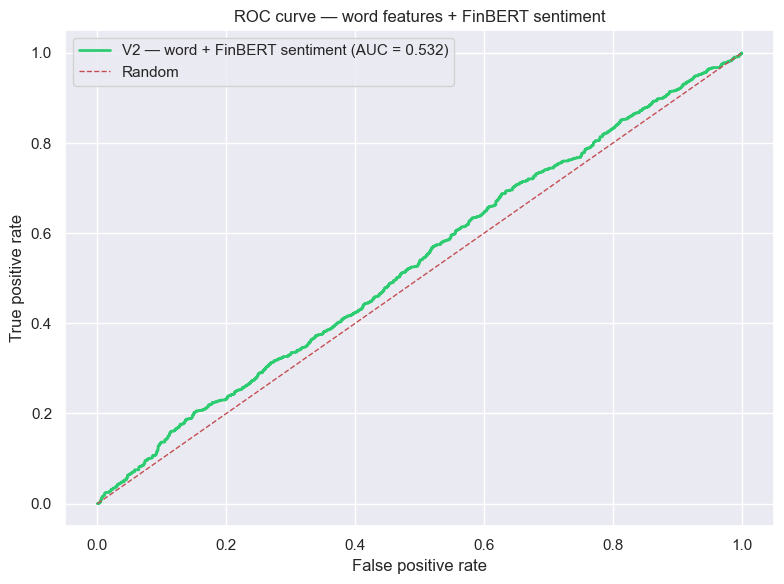


📊 Model V1 (word features only): AUC = 0.5356
📊 Model V2 (+ FinBERT sentiment): AUC = 0.5317
📈 Improvement: +-0.0039


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

fpr2, tpr2, _ = roc_curve(y2_test, y2_pred_prob)
ax.plot(fpr2, tpr2, color='#2ecc71', linewidth=2,
        label=f'V2 — word + FinBERT sentiment (AUC = {roc_auc_score(y2_test, y2_pred_prob):.3f})')

ax.plot([0,1],[0,1],'r--', linewidth=1, label='Random')
ax.set_title('ROC curve — word features + FinBERT sentiment')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/nlp_model_comparison.png', bbox_inches='tight')
plt.show()

print(f"\n📊 Model V1 (word features only): AUC = 0.5356")
print(f"📊 Model V2 (+ FinBERT sentiment): AUC = {roc_auc_score(y2_test, y2_pred_prob):.4f}")
print(f"📈 Improvement: +{roc_auc_score(y2_test, y2_pred_prob) - 0.5356:.4f}")